# 🟡 Pac-Man RL — Parte 0: conocer el ambiente

Todavía no implementamos Q-Learning.

Queremos verificar la misma interacción que usamos en FrozenLake y Taxi:

$$
(s_t,a_t)\rightarrow(r_{t+1},s_{t+1})
$$

La meta es crear el mundo, ejecutar acciones y visualizar un episodio completo dentro del notebook.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd "/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase05/pacman"

/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase05/pacman


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import random
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML
from matplotlib import animation

from pacman_env import PacmanEnv, ACTIONS


## 1. Crear el ambiente


In [ ]:
env = PacmanEnv(seed=7)
state = env.reset(seed=7)
state


PacmanState(pacman=(1, 1), ghost=(5, 7), food=30)

In [ ]:
print("Estado:", state)
print("Posición Pac-Man:", state.pacman)
print("Posición fantasma:", state.ghost)
print("Comida restante:", len(state.food))


Estado: PacmanState(pacman=(1, 1), ghost=(5, 7), food=30)
Posición Pac-Man: (1, 1)
Posición fantasma: (5, 7)
Comida restante: 30


## 2. Visualizar el estado


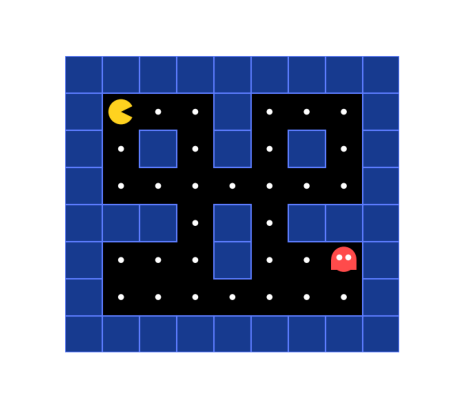

In [ ]:
frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


## 3. Acciones legales


In [ ]:
print(ACTIONS)

for action in env.get_legal_actions():
    print(action, "->", ACTIONS[action])


{0: 'North', 1: 'South', 2: 'East', 3: 'West', 4: 'Stop'}
1 -> South
2 -> East
4 -> Stop


## 4. Una transición

$$
(s_t,a_t)\rightarrow(r_{t+1},s_{t+1})
$$


In [ ]:
state = env.reset(seed=7)

action = random.choice(env.get_legal_actions())
next_state, reward, done, info = env.step(action)

print("s_t:", state)
print("a_t:", ACTIONS[action])
print("r_(t+1):", reward)
print("s_(t+1):", next_state)
print("done:", done)
print("info:", info)


s_t: PacmanState(pacman=(1, 1), ghost=(5, 7), food=30)
a_t: East
r_(t+1): 9
s_(t+1): PacmanState(pacman=(1, 2), ghost=(5, 6), food=29)
done: False
info: {'score': 9, 'steps': 1, 'food_remaining': 29, 'won': False, 'lost': False}


## 5. Random agent


In [ ]:
def random_episode(env, max_steps=100, seed=None):
    state = env.reset(seed=seed)

    frames = [env.render()]
    trajectory = []
    total_reward = 0

    for _ in range(max_steps):
        action = random.choice(env.get_legal_actions())

        next_state, reward, done, info = env.step(action)

        trajectory.append(
            {
                "state": state,
                "action": ACTIONS[action],
                "reward": reward,
                "next_state": next_state,
            }
        )

        frames.append(env.render())

        total_reward += reward
        state = next_state

        if done:
            break

    return frames, trajectory, total_reward, info


In [ ]:
frames, trajectory, total_reward, info = random_episode(
    env,
    max_steps=80,
    seed=12
)

print("Número de pasos:", len(trajectory))
print("Recompensa total:", total_reward)
print("Resultado:", info)


Número de pasos: 80
Recompensa total: 40
Resultado: {'score': 40, 'steps': 80, 'food_remaining': 18, 'won': False, 'lost': False}


## 6. Reproducir el episodio


In [ ]:
def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


In [ ]:
frames_to_video(frames, interval=300)

## 7. Interfaz lista para RL

Ya podemos trabajar con:

```python
state = env.reset()
legal_actions = env.get_legal_actions()
next_state, reward, done, info = env.step(action)
frame = env.render()
```

La siguiente etapa será construir $Q(s,a)$ sobre esta misma interfaz.
